librerias

In [28]:
#Data
import pandas as pd

#Plots
import matplotlib.pyplot as plt

#fits
#from scipy.optimize import curve_fit

#math
import numpy as np
import scipy.integrate as integrate


#Constants
from scipy.constants import physical_constants
m_u=physical_constants['atomic mass constant energy equivalent in MeV'][0]
from scipy.constants import speed_of_light as c
#from scipy.constants import Boltzmann as kb
#from scipy.constants import Stefan_Boltzmann as Sb

#Usefull
from tqdm.notebook import tqdm
import os
from scipy.interpolate import interp1d
import pynucastro as pyna
#%matplotlib widget

carga de datos

In [29]:
'''our model'''
data_con_teo=pd.read_csv('Results/epsilon_dot_in_theoretical_500.csv')
data_sin_teo=pd.read_csv('Results/epsilon_dot_out_theoretical_500.csv')
data_sin_teo_exp=pd.read_csv('Results/epsilon_dot_out_theoretical_exp.csv')
data_sin_teo_sin_Ir194=pd.read_csv('Results/epsilon_dot_sin_theoretical_sin_Ir194.csv')

time_days=data_con_teo['time_days']
time=time_days*86400 #convertir a segundos

Epsilon_alpha_in=data_con_teo['epsilon_dot_alpha']
Epsilon_beta_in=data_con_teo['epsilon_dot_beta_minus']
Epsilon_dot_in=data_con_teo['epsilon_dot']

Epsilon_alpha_out=data_sin_teo['epsilon_dot_alpha']
Epsilon_beta_out=data_sin_teo['epsilon_dot_beta_minus']
Epsilon_dot_out=data_sin_teo['epsilon_dot']

Epsilon_alpha_out_exp=data_sin_teo_exp['epsilon_dot_alpha']
Epsilon_beta_out_exp=data_sin_teo_exp['epsilon_dot_beta_minus'] 
Epsilon_dot_out_exp=data_sin_teo_exp['epsilon_dot']

Epsilon_alpha_out_sin_Ir194=data_sin_teo_sin_Ir194['epsilon_dot_alpha']
Epsilon_beta_out_sin_Ir194=data_sin_teo_sin_Ir194['epsilon_dot_beta_minus']
Epsilon_dot_out_sin_Ir194=data_sin_teo_sin_Ir194['epsilon_dot']

'''usefull data'''
data_usefull=pd.read_csv('Results/Usefull/out/Xa.csv')
Xa_out=data_usefull['Xa']
data_usefull2=pd.read_csv('Results/Usefull/in/Xa.csv')
Xa=data_usefull2['Xa']

In [10]:
''' Other Models for Heating Rate'''

#important parameters
Mey=0.05
Vey=0.15#c

#termalization Barnes 2016
a_th=0.27
b_th=0.1
d_th=0.6
e_th=0.36*(np.exp(-a_th*time_days)+np.log(1+2*b_th*time_days**d_th)/(2*b_th*time_days**d_th))

#termalization beta
ty=0.3*np.sqrt(Mey/0.01)*(0.2/Vey)*24*60*60 ##termalization gamma particles
f_gamma=1-np.exp(-(ty/time)**2)

#termalization Metzger 2010
e_Metzger_th=0.75


#Metzger 2010
E_metzger=e_Metzger_th*(3*10**10)*(time_days)**(-1.3)

#aproximation
E_korobkin=e_th*(4*10**18)*(0.5-(1/np.pi)*np.arctan((time-1.3)/0.11))**(1.3)

#Power Law Hotokezaka
E_hoto_e=(4*10**9)*(time_days)**(-1.3)
E_hoto_g=(8*10**9)*(time_days)**(-1.3)
E_hoto_a=(7*10**8)*(1/time_days)*(Xa/3e-2)
E_hoto_f=(2*10**9)*(1/time_days)*(Xa/2e-2)
E_Hoto=E_hoto_e+f_gamma*E_hoto_g+E_hoto_a+E_hoto_f

#power law Waxman 2018
e_wax=2E10
beta_wax=1.3
alpha_wax=3
kappa_wax=0.2
M_wax=0.05
v_wax=0.1
t_M=1.5*(1/np.sqrt(1+2*alpha_wax))*np.sqrt((kappa_wax/1)*(M_wax/0.01)*(0.1/v_wax))
E_waxman=e_wax*(time_days/t_M)**(-beta_wax)

#termalization for waxman
f_vy=0.7
kappa_e=1
f_e=kappa_e*((3*M_wax)/(4*np.pi*v_wax**3*(c*time)**2))<1
f_e=np.zeros(len(time_days))+1-1*f_e+f_e*kappa_e*((3*M_wax)/(4*np.pi*v_wax**3*(c*time)**2))
E_waxman_efectivo=(1-f_vy)*E_waxman*f_e

#XKN model
E_XKN=0.5*(10**10)*(time_days)**(-1.3)+2e10*np.exp(-time_days/1)

(0.1, 500.0)

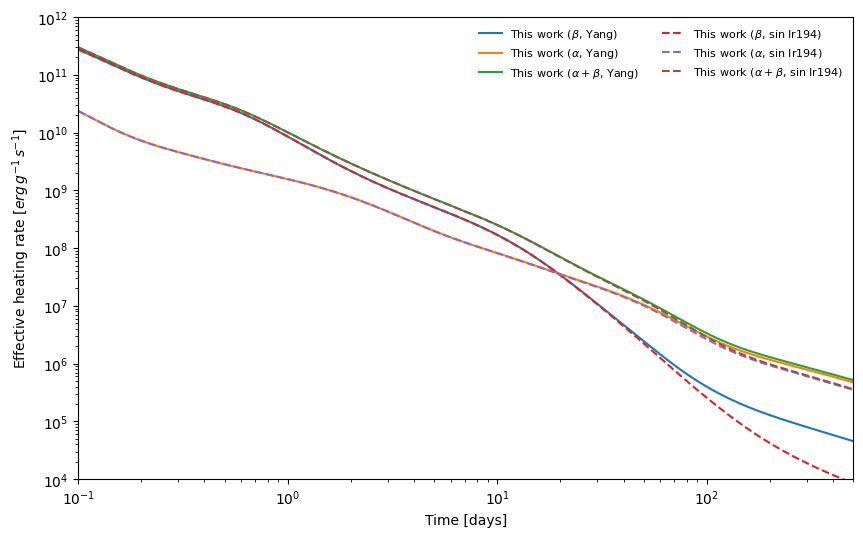

In [35]:
'''Figure 1. Our Heating rate compare to others models'''

plt.figure(figsize=(10,6))

'''
plt.plot(time_days,E_metzger,label=r'Metzger 2010 ($\beta$)',linestyle=':',alpha=0.5)

plt.plot(time_days,E_korobkin,label=r'Korobkin 2012 ($\beta+\alpha+SF$)',linestyle=':')

plt.plot(time_days,E_Hoto,label=r'Hotokezaka 2016 ($\beta+\alpha+SF$)',linestyle='-.')
plt.plot(time_days,E_waxman_efectivo,label=r'Waxman 2018 ($\beta+\alpha+sf$)',linestyle=':')
plt.plot(time_days,E_XKN,label=r'XKN model ($\beta+\alpha+sf$)',linestyle='--')


plt.plot(time_days,Epsilon_beta_in,label=r'This work ($\beta$, +teo, yang)',color='red')
plt.plot(time_days,Epsilon_alpha_in,label=r'This work ($\alpha$, +teo, yang)',color='green')
plt.plot(time_days,Epsilon_dot_in,label=r'This work ($\alpha+\beta$, +teo, yang)',color='blue')
'''


plt.plot(time_days,Epsilon_beta_out,label=r'This work ($\beta$, Yang)',linestyle='-')
plt.plot(time_days,Epsilon_alpha_out,label=r'This work ($\alpha$, Yang)',linestyle='-')
plt.plot(time_days,Epsilon_dot_out,label=r'This work ($\alpha+\beta$, Yang)',linestyle='-')
'''
plt.plot(time_days,Epsilon_beta_out_exp,label=r'This work ($\beta$, exp)',linestyle=':')
plt.plot(time_days,Epsilon_alpha_out_exp,label=r'This work ($\alpha$, exp)',linestyle=':')
plt.plot(time_days,Epsilon_dot_out_exp,label=r'This work ($\alpha+\beta$, exp)',linestyle=':')
'''
plt.plot(time_days,Epsilon_beta_out_sin_Ir194,label=r'This work ($\beta$, sin Ir194)',linestyle='--')
plt.plot(time_days,Epsilon_alpha_out_sin_Ir194,label=r'This work ($\alpha$, sin Ir194)',linestyle='--')
plt.plot(time_days,Epsilon_dot_out_sin_Ir194,label=r'This work ($\alpha+\beta$, sin Ir194)',linestyle='--')



plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e4,1e12))
plt.xlim((1e-1,5e2))

(0.1, 500.0)

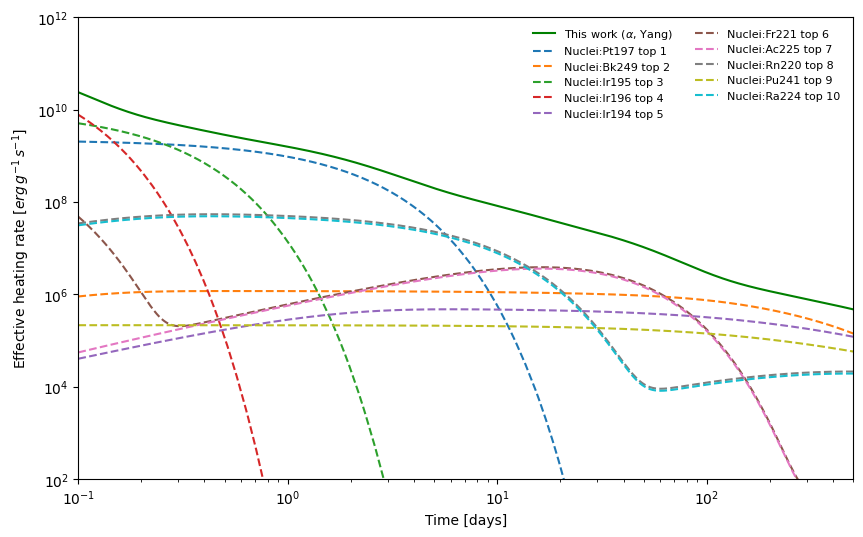

In [37]:
top = 10 # Define the number of top elements to display
plt.figure(figsize=(10,6))

'''
plt.plot(time_days,Epsilon_beta_in,label=r'This work ($\beta$, +teo)')
plt.plot(time_days,Epsilon_alpha_in,label=r'This work ($\alpha$, +teo)')
plt.plot(time_days,Epsilon_dot_in,label=r'This work ($\alpha+\beta$, +teo)')

plt.plot(time_days,Epsilon_beta_out,label=r'This work ($\beta$, -teo)',linestyle=':',color='darkblue')
plt.plot(time_days,Epsilon_alpha_out,label=r'This work ($\alpha$, -teo)',linestyle=':',color='darkorange')
plt.plot(time_days,Epsilon_dot_out,label=r'This work ($\alpha+\beta$, -teo)',linestyle=':',color='darkgreen')



for i in range(top):
    data_teo=pd.read_csv(f'Results/relevants_in_theo/alpha/epsilon_relevant_{i}.csv')
    plt.plot(data_teo['time_days'],data_teo.values[:,1],label=f'{data_teo.columns[1]} (alpha, +teo)')

plt.plot(time_days,Epsilon_alpha_in,label=r'This work ($\alpha$, +teo)')

'''

plt.plot(time_days,Epsilon_alpha_out,label=r'This work ($\alpha$, Yang)',color='green')
for i in range(top):
    data_teo=pd.read_csv(f'Results/relevants_out_theo/alpha/epsilon_relevant_{i}.csv')
    plt.plot(data_teo['time_days'],data_teo.values[:,1],label=f'{data_teo.columns[1]} ',linestyle='--')

'''
plt.plot(time_days,Epsilon_beta_out,label=r'This work ($\beta$, Yang)',color='red')
for i in range(top):
    data_teo=pd.read_csv(f'Results/relevants_out_theo/beta/epsilon_relevant_{i}.csv')
    plt.plot(data_teo['time_days'],data_teo.values[:,1],label=f'{data_teo.columns[1]}',linestyle='--')
'''

plt.yscale('log')
plt.xscale('log') 
plt.xlabel('Time [days]')
plt.ylabel(r'Effective heating rate $[erg\,g^{-1}\,s^{-1}]$')
plt.legend(loc="upper right", ncol=2,frameon=False,fontsize=8)
plt.ylim((1e2,1e12))
plt.xlim((0.1,5e2))
